In [1]:
import sys
print("Python version:", sys.version)

# Recommended versions
REQUIRED_VERSIONS = {
    "opencv-python": "4.8+",
    "mediapipe": "0.10+",
    "numpy": "1.23+",
    "pandas": "1.5+",
    "tensorflow": "2.12+",
    "scikit-learn": "1.3+",
    "matplotlib": "3.7+",
    "plotly": "5.15+"
}

REQUIRED_VERSIONS

Python version: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]


{'opencv-python': '4.8+',
 'mediapipe': '0.10+',
 'numpy': '1.23+',
 'pandas': '1.5+',
 'tensorflow': '2.12+',
 'scikit-learn': '1.3+',
 'matplotlib': '3.7+',
 'plotly': '5.15+'}

In [3]:
# !pip install opencv-python=="4.11.0.86"
# !pip install mediapipe=="0.10.7"
# !pip install numpy=="1.22.0"
# !pip install pandas=="1.5+"
# !pip install tensorflow=="2.12+"
# !pip install scikit-learn=="1.3+"
# !pip install matplotlib=="3.7+"
# !pip install plotly=="5.15+"

# 1. Imports

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import shutil
import gc

import mediapipe as mp

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns

# 2. Dataset Structure Loader

In [5]:
DATA_PATH = "data"

def list_dataset(base_path):
    for split in ["train", "test"]:
        print(f"\n=== {split.upper()} ===")
        split_path = os.path.join(base_path, split)
        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            print(f"{cls}: {len(os.listdir(cls_path))} videos")

list_dataset(DATA_PATH)


=== TRAIN ===
Fall Down: 415 videos
Lying Down: 380 videos
Sit down: 187 videos
Sitting: 315 videos
Stand up: 296 videos
Standing: 566 videos
Walking: 665 videos

=== TEST ===
Fall Down: 177 videos
Lying Down: 162 videos
Sit down: 79 videos
Sitting: 135 videos
Stand up: 126 videos
Standing: 242 videos
Walking: 285 videos


# 3. Split TRAIN → TRAIN + VAL

In [6]:
VAL_SPLIT_PATH = "data_split"

def split_train_val():
    train_path = os.path.join(DATA_PATH, "train")

    for cls in os.listdir(train_path):
        cls_path = os.path.join(train_path, cls)
        videos = glob.glob(os.path.join(cls_path, "*.avi"))

        train_files, val_files = train_test_split(videos, test_size=0.2, random_state=42)

        for split_name, files in [("train", train_files), ("val", val_files)]:
            for f in files:
                out_dir = os.path.join(VAL_SPLIT_PATH, split_name, cls)
                os.makedirs(out_dir, exist_ok=True)
                # os.system(f"cp \"{f}\" \"{out_dir}\"")
                shutil.move(f, out_dir)

    # Copy test as-is
    test_src = os.path.join(DATA_PATH, "test")
    test_dst = os.path.join(VAL_SPLIT_PATH, "test")

    # os.system(f"cp -r \"{test_src}\" \"{test_dst}\"")
    shutil.move(test_src, test_dst)

split_train_val()

# 4. MediaPipe Keypoint Extraction

In [7]:
mp_pose = mp.solutions.pose

pose = mp_pose.Pose()  # ✅ create ONCE

def extract_keypoints_to_csv(video_path):
    csv_path = video_path.replace(".avi", ".csv")

    if os.path.exists(csv_path):
        return

    cap = cv2.VideoCapture(video_path)

    keypoints_seq = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = pose.process(img)

        if result.pose_landmarks:
            frame_kp = []
            for lm in result.pose_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z])
        else:
            frame_kp = [0] * (33 * 3)

        keypoints_seq.append(frame_kp)

    cap.release()
    del cap
    gc.collect()

    if len(keypoints_seq) == 0:
        keypoints_seq = [[0]*(33*3) for _ in range(30)]

    if len(keypoints_seq) < 30:
        last = keypoints_seq[-1]
        while len(keypoints_seq) < 30:
            keypoints_seq.append(last)
    else:
        keypoints_seq = keypoints_seq[:30]

    df = pd.DataFrame(keypoints_seq)
    df.to_csv(csv_path, index=False)

# 4.b Data Extraction Stage:

In [8]:
def process_all_videos_to_csv():
    for split in ["train", "val", "test"]:
        split_path = os.path.join("data_split", split)

        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)

            videos = glob.glob(os.path.join(cls_path, "*.avi"))

            for v in tqdm(videos, desc=f"{split}-{cls}"):
                extract_keypoints_to_csv(v)

process_all_videos_to_csv()

test-Walking: 100%|██████████████████████████████████████████████████████████████████| 285/285 [13:59<00:00,  2.95s/it]


# 5. Build Dataset

In [9]:
VAL_SPLIT_PATH = "data_split"


def load_dataset(split):
    X, y = [], []

    split_path = os.path.join(VAL_SPLIT_PATH, split)

    # Only keep valid class folders
    classes = sorted([
        d for d in os.listdir(split_path)
        if os.path.isdir(os.path.join(split_path, d))
    ])

    class_map = {c: i for i, c in enumerate(classes)}

    for cls in classes:
        cls_path = os.path.join(split_path, cls)

        csv_files = glob.glob(os.path.join(cls_path, "*.csv"))

        for f in tqdm(csv_files, desc=f"{split}-{cls}"):

            try:
                df = pd.read_csv(f)
                data = df.values

                # ✅ HARD SAFETY CHECK
                if data.shape != (30, 99):
                    print(f"[SKIP] Bad shape {data.shape}: {f}")
                    continue

                # ✅ Optional: skip empty samples
                if np.all(data == 0):
                    print(f"[SKIP] Empty sample: {f}")
                    continue

                X.append(data)
                y.append(class_map[cls])

            except Exception as e:
                print(f"[ERROR] {f}: {e}")
                continue

    X = np.array(X, dtype=np.float32)
    y = tf.keras.utils.to_categorical(y, num_classes=len(classes))

    return X, y, classes


X_train, y_train, classes = load_dataset("train")
X_val, y_val, _ = load_dataset("val")
# X_test, y_test, _ = load_dataset("test")

print("Train:", X_train.shape)
print("Val:", X_val.shape)
# print("Test:", X_test.shape)

train-Fall Down:   8%|█████▍                                                          | 28/332 [00:00<00:03, 95.30it/s]

[SKIP] Empty sample: data_split\train\Fall Down\video_111.csv
[SKIP] Empty sample: data_split\train\Fall Down\video_119_flip.csv


train-Fall Down:  23%|██████████████▏                                                | 75/332 [00:00<00:02, 113.64it/s]

[SKIP] Empty sample: data_split\train\Fall Down\video_155.csv
[SKIP] Empty sample: data_split\train\Fall Down\video_155_flip.csv
[SKIP] Empty sample: data_split\train\Fall Down\video_158.csv
[SKIP] Empty sample: data_split\train\Fall Down\video_167_flip.csv
[SKIP] Empty sample: data_split\train\Fall Down\video_168.csv
[SKIP] Empty sample: data_split\train\Fall Down\video_168_flip.csv
[SKIP] Empty sample: data_split\train\Fall Down\video_171_flip.csv


train-Fall Down:  30%|██████████████████▊                                            | 99/332 [00:00<00:02, 109.59it/s]

...

[SKIP] Empty sample: data_split\val\Walking\video_239.csv
[SKIP] Empty sample: data_split\val\Walking\video_242_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_259_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_279.csv
[SKIP] Empty sample: data_split\val\Walking\video_279_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_287_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_288.csv
[SKIP] Empty sample: data_split\val\Walking\video_292_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_295_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_315_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_318_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_323_flip.csv
[SKIP] Empty sample: data_split\val\Walking\video_335_flip.csv


val-Walking:  74%|█████████████████████████████████████████████████▎                 | 98/133 [00:00<00:00, 127.61it/s]

[SKIP] Empty sample: data_split\val\Walking\video_337.csv
[SKIP] Empty sample: data_split\val\Walking\video_439.csv
[SKIP] Empty sample: data_split\val\Walking\video_449_flip.csv


val-Walking: 100%|██████████████████████████████████████████████████████████████████| 133/133 [00:01<00:00, 121.22it/s]

Train: (1967, 30, 99)
Val: (477, 30, 99)


In [10]:
print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (1967, 30, 99)
Val: (477, 30, 99)


# 6. LSTM Model

## 6.a Model

In [11]:
def build_model(input_shape, num_classes):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(64),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model((30, 99), len(classes))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 128)           116736    
                                                                 
 dropout (Dropout)           (None, 30, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 7)                 455       
                                                                 
Total params: 170,759
Trainable params: 170,759
Non-trainable params: 0
_________________________________________________________________


## 6.b Training

In [29]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32
)

Epoch 1/200
62/62 [==============================] - 1s 20ms/step - loss: 0.1620 - accuracy: 0.9446 - val_loss: 1.3666 - val_accuracy: 0.7421
Epoch 2/200
62/62 [==============================] - 1s 19ms/step - loss: 0.0940 - accuracy: 0.9675 - val_loss: 1.5336 - val_accuracy: 0.7086
Epoch 3/200
62/62 [==============================] - 1s 19ms/step - loss: 0.0844 - accuracy: 0.9700 - val_loss: 1.4165 - val_accuracy: 0.7358
Epoch 4/200
62/62 [==============================] - 1s 19ms/step - loss: 0.0506 - accuracy: 0.9817 - val_loss: 1.5007 - val_accuracy: 0.7296
Epoch 5/200
62/62 [==============================] - 1s 19ms/step - loss: 0.0485 - accuracy: 0.9847 - val_loss: 1.5392 - val_accuracy: 0.7379
Epoch 6/200
62/62 [==============================] - 1s 19ms/step - loss: 0.0356 - accuracy: 0.9888 - val_loss: 1.5165 - val_accuracy: 0.7421
Epoch 7/200
62/62 [==============================] - 1s 20ms/step - loss: 0.0381 - accuracy: 0.9863 - val_loss: 1.5748 - val_accuracy: 0.7317
Epoch 

## 6.c Evaluation

In [30]:
X_test, y_test, _ = load_dataset("test")

test-Fall Down:  40%|█████████████████████████▋                                      | 71/177 [00:00<00:00, 360.55it/s]

[SKIP] Empty sample: data_split\test\Fall Down\video_124_flip.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_141.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_157.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_157_flip.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_167.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_180_flip.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_182.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_204.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_208.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_214_flip.csv


test-Fall Down: 100%|███████████████████████████████████████████████████████████████| 177/177 [00:00<00:00, 405.44it/s]


[SKIP] Empty sample: data_split\test\Fall Down\video_249.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_255.csv
[SKIP] Empty sample: data_split\test\Fall Down\video_88.csv


test-Lying Down:  32%|████████████████████▏                                          | 52/162 [00:00<00:00, 486.22it/s]

...

[SKIP] Empty sample: data_split\test\Walking\video_118.csv
[SKIP] Empty sample: data_split\test\Walking\video_119_flip.csv
[SKIP] Empty sample: data_split\test\Walking\video_120_flip.csv
[SKIP] Empty sample: data_split\test\Walking\video_123.csv
[SKIP] Empty sample: data_split\test\Walking\video_130_flip.csv
[SKIP] Empty sample: data_split\test\Walking\video_142.csv


test-Walking:  52%|█████████████████████████████████▉                               | 149/285 [00:00<00:00, 480.71it/s]

[SKIP] Empty sample: data_split\test\Walking\video_260_flip.csv
[SKIP] Empty sample: data_split\test\Walking\video_288_flip.csv
[SKIP] Empty sample: data_split\test\Walking\video_290.csv
[SKIP] Empty sample: data_split\test\Walking\video_290_flip.csv
[SKIP] Empty sample: data_split\test\Walking\video_291.csv
[SKIP] Empty sample: data_split\test\Walking\video_295.csv
[SKIP] Empty sample: data_split\test\Walking\video_305.csv
[SKIP] Empty sample: data_split\test\Walking\video_315.csv
[SKIP] Empty sample: data_split\test\Walking\video_323.csv
[SKIP] Empty sample: data_split\test\Walking\video_334_flip.csv
[SKIP] Empty sample: data_split\test\Walking\video_349.csv
[SKIP] Empty sample: data_split\test\Walking\video_359.csv
[SKIP] Empty sample: data_split\test\Walking\video_363_flip.csv


test-Walking: 100%|█████████████████████████████████████████████████████████████████| 285/285 [00:00<00:00, 483.11it/s]

[SKIP] Empty sample: data_split\test\Walking\video_441.csv
[SKIP] Empty sample: data_split\test\Walking\video_446_flip.csv
[SKIP] Empty sample: data_split\test\Walking\video_457.csv
[SKIP] Empty sample: data_split\test\Walking\video_473.csv
[SKIP] Empty sample: data_split\test\Walking\video_473_flip.csv


In [31]:
print("Test:", X_test.shape)

Test: (1084, 30, 99)


In [32]:
y_pred = model.predict(X_test)

y_pred_cls = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_cls, target_names=classes))

34/34 [==============================] - 0s 7ms/step
              precision    recall  f1-score   support

   Fall Down       0.83      0.78      0.80       164
  Lying Down       0.75      0.87      0.81       132
    Sit down       0.65      0.53      0.58        75
     Sitting       0.68      0.68      0.68       112
    Stand up       0.74      0.65      0.69       116
    Standing       0.60      0.59      0.59       224
     Walking       0.66      0.71      0.69       261

    accuracy                           0.69      1084
   macro avg       0.70      0.69      0.69      1084
weighted avg       0.69      0.69      0.69      1084



## Confusion Matrix

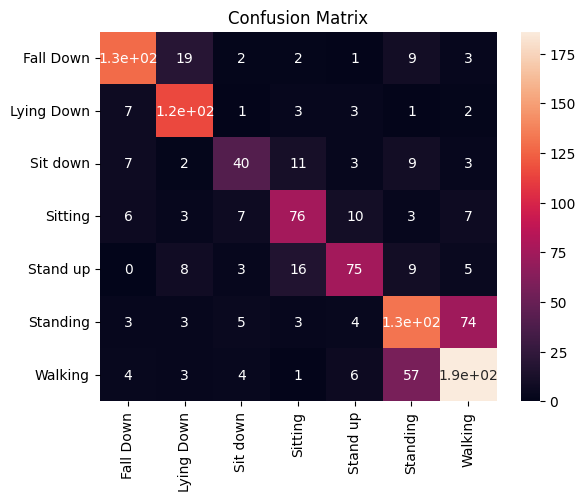

In [33]:
cm = confusion_matrix(y_true, y_pred_cls)
sns.heatmap(cm, annot=True, xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()

# Predictions:

In [34]:
def predict_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    data = df.values

    if data.shape != (30, 99):
        return None

    X = np.expand_dims(data, axis=0)
    pred = model.predict(X, verbose=0)

    pred_class = np.argmax(pred)
    return pred_class, pred

In [35]:
def visualize_one_per_class():
    test_path = os.path.join(VAL_SPLIT_PATH, "test")

    for cls in classes:
        cls_path = os.path.join(test_path, cls)

        csv_files = glob.glob(os.path.join(cls_path, "*.csv"))
        if len(csv_files) == 0:
            continue

        # pick first sample
        csv_path = csv_files[0]
        video_path = csv_path.replace(".csv", ".avi")

        result = predict_from_csv(csv_path)
        if result is None:
            print(f"[SKIP] Bad CSV: {csv_path}")
            continue

        pred_class, _ = result
        pred_label = classes[pred_class]
        true_label = cls

        print(f"\nShowing: {video_path}")
        print(f"TRUE: {true_label} | PRED: {pred_label}")

        cap = cv2.VideoCapture(video_path)

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # 🎯 Overlay labels
            cv2.rectangle(frame, (10, 10), (600, 100), (0, 0, 0), -1)

            cv2.putText(frame,
                        f"TRUE: {true_label}",
                        (20, 40),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.9,
                        (0, 255, 0),
                        2)

            cv2.putText(frame,
                        f"PRED: {pred_label}",
                        (20, 80),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.9,
                        (0, 0, 255),
                        2)

            cv2.imshow("Evaluation Viewer", frame)

            # press q to skip to next class
            if cv2.waitKey(30) & 0xFF == ord('q'):
                break

        cap.release()

    cv2.destroyAllWindows()

In [36]:
visualize_one_per_class()


Showing: data_split\test\Fall Down\video_1.avi
TRUE: Fall Down | PRED: Fall Down

Showing: data_split\test\Lying Down\video_0.avi
TRUE: Lying Down | PRED: Lying Down

Showing: data_split\test\Sit down\video_101_flip.avi
TRUE: Sit down | PRED: Sit down

Showing: data_split\test\Sitting\video_0_flip.avi
TRUE: Sitting | PRED: Sitting

Showing: data_split\test\Stand up\video_10.avi
TRUE: Stand up | PRED: Stand up

Showing: data_split\test\Standing\video_100_flip.avi
TRUE: Standing | PRED: Standing

Showing: data_split\test\Walking\video_100.avi
TRUE: Walking | PRED: Walking
